<a href="https://colab.research.google.com/github/w3aarush/DR_Classification_NIT_MCA_Project/blob/main/EfficientnetV2S_DR_Hyperparameter_Tuning_Kriti_approach.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.applications.efficientnet_v2 import EfficientNetV2S, preprocess_input
from tensorflow.keras import layers,Model
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve, accuracy_score
from google.colab.patches import cv2_imshow

import time
import os

# from cuml import SVC # for python 3.11
# from sklearn.svm import SVC
# import imutils

In [2]:
# # Install Kaggle API
# !pip install -q kaggle

# # Upload kaggle.json
# from google.colab import files
# files.upload()

# # Setup Kaggle API
# !mkdir -p ~/.kaggle
# !cp kaggle.json ~/.kaggle/kaggle.json
# !chmod 600 ~/.kaggle/kaggle.json

# # Download DATASET (not competition)
# !kaggle datasets download -d mariaherrerot/aptos2019

# # Unzip
# !unzip -q aptos2019.zip -d aptos2019

# # Check files
# !ls aptos2019

In [3]:
# base_dir = '/content/aptos2019'
# train_dir = '/content/aptos2019/train_images/train_images/'
# validation_dir = '/content/aptos2019/val_images/val_images/'
# test_dir = '/content/aptos2019/test_images/test_images/'

In [4]:
# from drive
base_dir = '/content/drive/MyDrive/aptos2019/'
train_img = '/content/drive/MyDrive/aptos2019/train_images/train_images/'
validation_img = '/content/drive/MyDrive/aptos2019/val_images/val_images/'
test_img = '/content/drive/MyDrive/aptos2019/test_images/test_images/'

train_csv = '/content/drive/MyDrive/aptos2019/train_1.csv'
test_csv = '/content/drive/MyDrive/aptos2019/test.csv'
valid_csv = '/content/drive/MyDrive/aptos2019/valid.csv'

In [5]:
NUM_CLASSES = 5
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
epochs = 20

### CLAHE

In [6]:
def apply_clahe_to_image_tensor(image_tensor):
    # image_tensor has shape (H, W, C) for a single image, float32, in [0, 255]
    # Convert to uint8 for OpenCV operations
    image_np_uint8 = tf.cast(image_tensor, tf.uint8).numpy()

    # Convert RGB to LAB color space to apply CLAHE only to the Lightness channel
    lab = cv2.cvtColor(image_np_uint8, cv2.COLOR_RGB2LAB)
    l_channel, a_channel, b_channel = cv2.split(lab)

    # Apply CLAHE to the L channel
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8)) # You can adjust clipLimit and tileGridSize
    cl = clahe.apply(l_channel)

    # Merge the CLAHE enhanced L channel with the original A and B channels
    limg = cv2.merge((cl, a_channel, b_channel))

    # Convert LAB back to RGB
    final_img_np_rgb = cv2.cvtColor(limg, cv2.COLOR_LAB2RGB)

    # Convert back to float32 and return as TensorFlow tensor
    return tf.convert_to_tensor(final_img_np_rgb, dtype=tf.float32)

# Wrapper function to apply CLAHE to a batch of images using tf.map_fn
def apply_clahe_batch(images_batch_tensor):
    # tf.map_fn applies a function to each element (image) in the batch
    return tf.map_fn(
        fn=lambda img: tf.py_function(apply_clahe_to_image_tensor, [img], tf.float32),
        elems=images_batch_tensor,
        fn_output_signature=tf.TensorSpec(images_batch_tensor.shape[1:], dtype=tf.float32)
    )

## Image Augmentation

In [7]:
img_augmentation = Sequential(
    [
        # tf.keras.layers.Lambda(apply_clahe_batch), # Apply CLAHE first
        tf.keras.layers.RandomRotation(factor=(-0.15, 0.15)),
        tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
        tf.keras.layers.RandomFlip(),
        tf.keras.layers.RandomContrast(factor=0.6),
    ],
    name="img_augmentation",
)

### loading dataset

In [8]:
def load_data():
    # train = pd.read_csv('/content/aptos2019/train_1.csv', encoding='utf-8')
    # test = pd.read_csv('/content/aptos2019/test.csv', encoding='utf-8')
    # valid = pd.read_csv('/content/aptos2019/valid.csv')

    train = pd.read_csv(train_csv, encoding='utf-8') # from drive
    test = pd.read_csv(test_csv, encoding='utf-8') # from drive
    valid = pd.read_csv(valid_csv) # from drive

    # train_dir = '/content/aptos2019/train_images/train_images/'
    # test_dir = '/content/aptos2019/test_images/test_images/'
    # valid_dir = '/content/aptos2019/val_images/val_images/'

    train_dir = train_img # from drive
    test_dir = test_img # from drive
    valid_dir = validation_img # from drive

    # construct file paths directly within function:
    train['image_path'] = train_dir + train['id_code'] + '.png'
    test['image_path'] = test_dir + test['id_code'] + '.png'
    valid['image_path'] = valid_dir + valid['id_code'] + '.png'

    train['train_images'] = train['id_code'] + '.png'
    test['test_images'] = test['id_code'] + '.png'
    valid['valid_images'] = valid['id_code'] + '.png'

    train['diagnosis'] = train['diagnosis'].astype(str)
    # train['target'] = [1 if x >= 1 else 0 for x in train['diagnosis']]
    # train['target'] = train['target'].astype(str)
    test['diagnosis'] = test['diagnosis'].astype(str)
    # test['target'] = [1 if x >= 1 else 0 for x in test['diagnosis']]
    # test['target'] = test['target'].astype(str)
    valid['diagnosis'] = valid['diagnosis'].astype(str)
    # valid['target'] = [1 if x >= 1 else 0 for x in valid['diagnosis']]
    # valid['target'] = valid['target'].astype(str)

    return train, test, valid

In [9]:
train_df, test_df, valid_df = load_data()

In [10]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id_code       2930 non-null   object
 1   diagnosis     2930 non-null   object
 2   image_path    2930 non-null   object
 3   train_images  2930 non-null   object
dtypes: object(4)
memory usage: 91.7+ KB


In [11]:
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   id_code      366 non-null    object
 1   diagnosis    366 non-null    object
 2   image_path   366 non-null    object
 3   test_images  366 non-null    object
dtypes: object(4)
memory usage: 11.6+ KB


In [12]:
valid_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   id_code       366 non-null    object
 1   diagnosis     366 non-null    object
 2   image_path    366 non-null    object
 3   valid_images  366 non-null    object
dtypes: object(4)
memory usage: 11.6+ KB


### Verifying `img_augmentation`

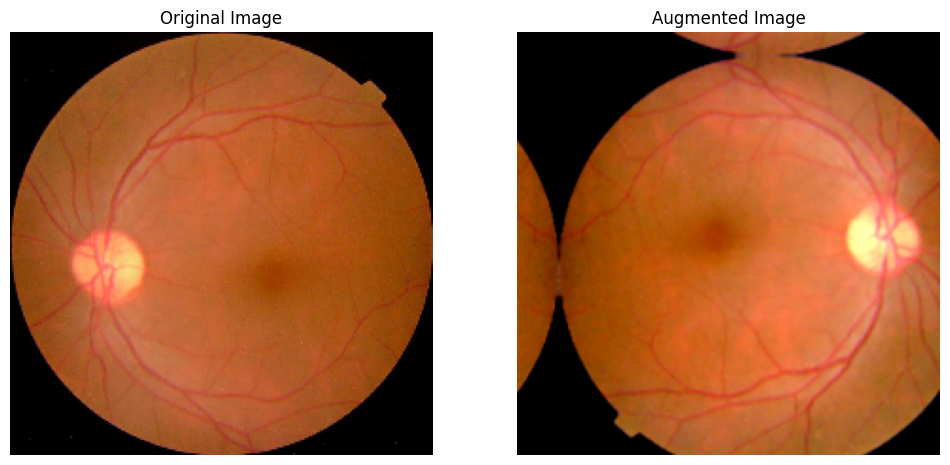

In [ ]:
# Select a random image from the training DataFrame
sample_image_path = train_df.sample(1).iloc[0]['image_path']

# Load the image using OpenCV (or PIL/Keras load_img)
original_img = cv2.imread(sample_image_path)
original_img = cv2.cvtColor(original_img, cv2.COLOR_BGR2RGB) # Convert BGR to RGB
original_img = cv2.resize(original_img, IMG_SIZE) # Resize to target size

# Convert to TensorFlow tensor and add batch dimension
img_tensor = tf.convert_to_tensor(original_img, dtype=tf.float32)
img_tensor = tf.expand_dims(img_tensor, axis=0) # Add batch dimension

# Apply the augmentation sequence
augmented_img_tensor = img_augmentation(img_tensor, training=True) # training=True enables random augmentations

# Convert augmented image back to NumPy array for display
augmented_img = augmented_img_tensor.numpy()[0]

# Ensure values are in displayable range (e.g., [0, 255] for uint8 or [0, 1] for float)
# The img_augmentation layers (like RandomContrast) keep values generally within 0-255.
# If CLAHE or other ops push values outside, it's good practice to clip or normalize for display.
augmented_img = np.clip(augmented_img, 0, 255).astype(np.uint8)

# Plot original and augmented images
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.imshow(original_img)
plt.title('Original Image')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(augmented_img)
plt.title('Augmented Image')
plt.axis('off')

plt.show()

In [13]:
def load_and_preprocess_image(image_path):
    img = load_img(image_path, target_size=(224, 224))
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis = 0)
    return preprocess_input(img_array)
    # return img_array

In [14]:
train_df.describe()

,id_code,diagnosis,image_path,train_images
count,2930,2930,2930,2930
unique,2930,5,2930,2930
top,e4d3d437b0a8,0,/content/drive/MyDrive/aptos2019/train_images/...,e4d3d437b0a8.png
freq,1,1434,1,1


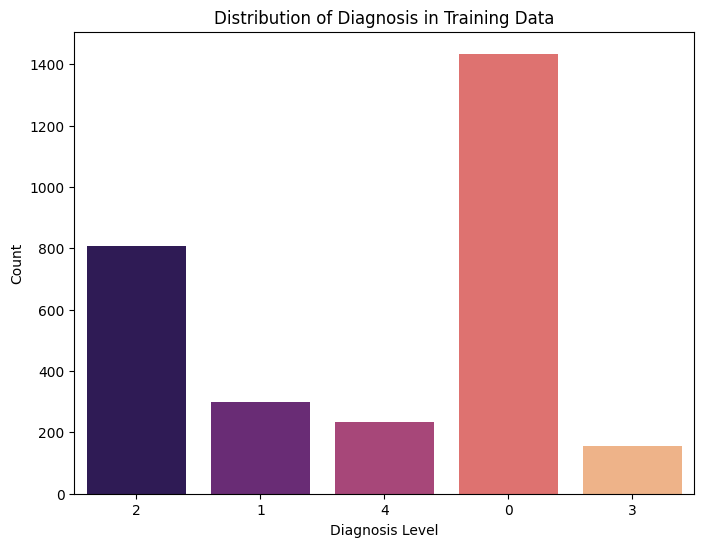

In [ ]:
# bar plot on diagnosis
plt.figure(figsize=(8, 6))
sns.countplot(data=train_df, x='diagnosis', palette='magma', hue='diagnosis')
plt.title('Distribution of Diagnosis in Training Data')
plt.xlabel('Diagnosis Level')
plt.ylabel('Count')
plt.show()

In [ ]:
train_df['diagnosis'].value_counts()

,count
diagnosis,
0,1434
2,808
1,300
4,234
3,154


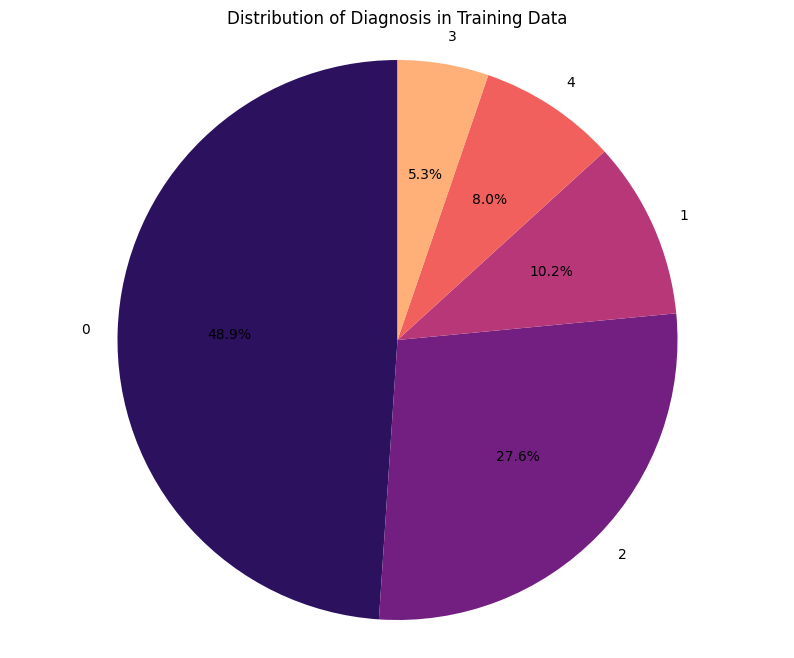

In [ ]:
# pie chart on diagnosis
diagnosis_counts = train_df['diagnosis'].value_counts()

plt.figure(figsize=(10, 8))
plt.pie(diagnosis_counts, labels=diagnosis_counts.index, autopct='%1.1f%%', startangle=90, colors=sns.color_palette('magma', len(diagnosis_counts)))
plt.title('Distribution of Diagnosis in Training Data')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

In [ ]:
((train_df['diagnosis'].value_counts())/len(train_df))*100

,count
diagnosis,
0,48.941980
2,27.576792
1,10.238908
4,7.986348
3,5.255973


### Sample Images from Training Data

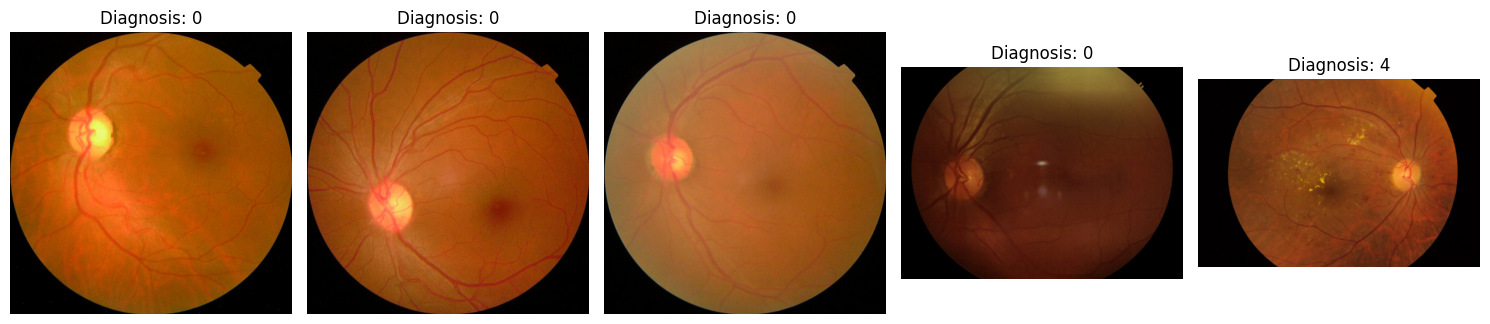

In [ ]:
num_samples = 5
sample_df = train_df.sample(n=num_samples) # random_state removed

plt.figure(figsize=(15, 10))
for i, row in enumerate(sample_df.itertuples()):
    image_path = row.image_path
    diagnosis = row.diagnosis

    img = cv2.imread(image_path)
    if img is not None:
        # Convert BGR to RGB for matplotlib display
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, num_samples, i + 1)
        plt.imshow(img_rgb)
        plt.title(f'Diagnosis: {diagnosis}')
        plt.axis('off')
    else:
        print(f"Could not load image: {image_path}")
plt.tight_layout()
plt.show()

### input data batch generation

In [15]:
train_batches = ImageDataGenerator().flow_from_dataframe(
        dataframe=train_df, x_col='image_path', y_col='diagnosis', target_size=(224,224), batch_size=BATCH_SIZE)

valid_batches = ImageDataGenerator().flow_from_dataframe(
        dataframe=valid_df, x_col='image_path', y_col='diagnosis', target_size=(224,224), batch_size=BATCH_SIZE)

test_batches = ImageDataGenerator().flow_from_dataframe(
        dataframe=test_df, x_col='image_path', y_col='diagnosis', target_size=(224,224), batch_size=BATCH_SIZE, shuffle=False)

Found 2930 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.
Found 366 validated image filenames belonging to 5 classes.


# Build Model

In [16]:
# Load the EfficientNetV2S base model without the top (classification) layer
base_model = EfficientNetV2S(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')

# Freeze the base model layers
base_model.trainable = False

# Create a new model on top of the base model using the Functional API
inputs = keras.Input(shape=IMG_SIZE + (3,))
x = img_augmentation(inputs) # Apply custom augmentation
x = preprocess_input(x) # EfficientNetV2S expects inputs in the [-1, 1] range after preprocessing
x = base_model(x, training=False) # Pass through the pre-trained base model
x = layers.GlobalAveragePooling2D()(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
model = keras.Model(inputs, outputs)

# Compile the model
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

82420632/82420632 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


### Training model

In [17]:
from tensorflow.keras.callbacks import ModelCheckpoint

In [18]:
callbacks = [
    ModelCheckpoint(filepath='effnetv2s_K_approach.h5', save_best_only=True, monitor='val_accuracy', mode='max', verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, mode='max', verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-4, verbose=1)
]

In [ ]:
history = model.fit(train_batches, epochs=20, validation_data=valid_batches, verbose=1, callbacks=callbacks)
epoch_history = pd.DataFrame(history.history)
epoch_history.to_csv('/content/drive/MyDrive/ML Projects/trained_models/17052026_EfficientV2s_untuned_epoch_history.csv')
model_path = '/content/drive/MyDrive/ML Projects/trained_models/17052026_EfficientV2s_untuned.keras'
mode.save(model_path)

Epoch 1/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 17s/step - accuracy: 0.3506 - loss: 1.4747 
Epoch 1: val_accuracy improved from None to 0.50273, saving model to effnetv2s_K_approach.h5



Epoch 1: finished saving model to effnetv2s_K_approach.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 1827s 20s/step - accuracy: 0.4375 - loss: 1.3465 - val_accuracy: 0.5027 - val_loss: 1.1400 - learning_rate: 1.0000e-04
Epoch 2/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5643 - loss: 1.1507
Epoch 2: val_accuracy improved from 0.50273 to 0.58743, saving model to effnetv2s_K_approach.h5



Epoch 2: finished saving model to effnetv2s_K_approach.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 405s 4s/step - accuracy: 0.5840 - loss: 1.1085 - val_accuracy: 0.5874 - val_loss: 1.0440 - learning_rate: 1.0000e-04
Epoch 3/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6174 - loss: 1.0715
Epoch 3: val_accuracy improved from 0.58743 to 0.63934, saving model to effnetv2s_K_approach.h5



Epoch 3: finished saving model to effnetv2s_K_approach.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 398s 4s/step - accuracy: 0.6454 - loss: 1.0222 - val_accuracy: 0.6393 - val_loss: 0.9782 - learning_rate: 1.0000e-04
Epoch 4/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6678 - loss: 0.9847
Epoch 4: val_accuracy improved from 0.63934 to 0.66393, saving model to effnetv2s_K_approach.h5



Epoch 4: finished saving model to effnetv2s_K_approach.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 400s 4s/step - accuracy: 0.6737 - loss: 0.9665 - val_accuracy: 0.6639 - val_loss: 0.9349 - learning_rate: 1.0000e-04
Epoch 5/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6621 - loss: 0.9471
Epoch 5: val_accuracy improved from 0.66393 to 0.67213, saving model to effnetv2s_K_approach.h5



Epoch 5: finished saving model to effnetv2s_K_approach.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 397s 4s/step - accuracy: 0.6799 - loss: 0.9157 - val_accuracy: 0.6721 - val_loss: 0.9050 - learning_rate: 1.0000e-04
Epoch 6/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6951 - loss: 0.8830
Epoch 6: val_accuracy did not improve from 0.67213
92/92 ━━━━━━━━━━━━━━━━━━━━ 397s 4s/step - accuracy: 0.6915 - loss: 0.8942 - val_accuracy: 0.6694 - val_loss: 0.8807 - learning_rate: 1.0000e-04
Epoch 7/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.6971 - loss: 0.8516
Epoch 7: val_accuracy improved from 0.67213 to 0.68852, saving model to effnetv2s_K_approach.h5



Epoch 7: finished saving model to effnetv2s_K_approach.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 397s 4s/step - accuracy: 0.6922 - loss: 0.8594 - val_accuracy: 0.6885 - val_loss: 0.8595 - learning_rate: 1.0000e-04
Epoch 8/20
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.7168 - loss: 0.8367
Epoch 8: val_accuracy improved from 0.68852 to 0.69399, saving model to effnetv2s_K_approach.h5



Epoch 8: finished saving model to effnetv2s_K_approach.h5
92/92 ━━━━━━━━━━━━━━━━━━━━ 402s 4s/step - accuracy: 0.7082 - loss: 0.8418 - val_accuracy: 0.6940 - val_loss: 0.8398 - learning_rate: 1.0000e-04
Epoch 9/20
 6/92 ━━━━━━━━━━━━━━━━━━━━ 5:29 4s/step - accuracy: 0.7217 - loss: 0.8445

## Fine Tune

In [ ]:
model = None # load model
base_model = model.layers[2]
base_model.trainable = True

In [ ]:
for layer in base_model.layers[:-100]:
    layer.trainable = False

In [ ]:
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
find_tuned_effnetv2s = model.fit(train_batches,
                                 epochs=20,
                                 validation_data=valid_batches,
                                 verbose=1, callbacks=callbacks
                                 )

<hr />

## Hyperparameter tuning

In [ ]:
import keras_tuner as kt

def build_tunable_model(hp):
    # Load the EfficientNetV2s base model without the top (classification) layer
    base_model = EfficientNetV2S(input_shape=IMG_SIZE + (3,), include_top=False, weights='imagenet')

    # Freeze the base model layers
    base_model.trainable = False

    # Create a new model on top of the base model using the Functional API
    inputs = keras.Input(shape=IMG_SIZE + (3,))
    x = img_augmentation(inputs) # Apply custom augmentation
    x = preprocess_input(x) # EfficientNetV2S expects inputs in the [-1, 1] range after preprocessing
    x = base_model(x, training=False) # Pass through the pre-trained base model
    x = layers.GlobalAveragePooling2D()(x)

    # Tune the number of hidden layers and units
    for i in range(hp.Int('num_dense_layers', 1, 3)):
        x = layers.Dense(units=hp.Int(f'units_{i}', min_value=32, max_value=256, step=32),
                         activation='relu')(x)
        x = layers.Dropout(hp.Float(f'dropout_{i}', min_value=0.2, max_value=0.5, step=0.1))(x)

    outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
    model = keras.Model(inputs, outputs)

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=hp_learning_rate),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

# Initialize the Keras Tuner
tuner = kt.RandomSearch(
    build_tunable_model,
    objective='val_accuracy',
    max_trials=10,  # Number of different hyperparameter combinations to try
    executions_per_trial=2,  # Number of models to train for each trial (to reduce variance)
    directory='keras_tuner_dir', # Directory to save tuning results
    project_name='aptos_efficientnet_tuning'
)

# Display a summary of the search space
tuner.search_space_summary()

# Run the hyperparameter search
print("Starting hyperparameter search...")
tuner.search(
    train_batches,
    epochs=10, # You can adjust this for tuning, usually fewer epochs than final training
    validation_data=valid_batches,
    callbacks=callbacks
)

print("Hyperparameter search complete.")

# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
print(f"The best learning rate found by the tuner is {best_hps.get('learning_rate')}.")
print(f"The best number of dense layers found is {best_hps.get('num_dense_layers')}.")
# You can print other best hyperparameters similarly

# Build the model with the optimal hyperparameters and train it
# best_model = tuner.hypermodel.build(best_hps)
# history_tuned = best_model.fit(train_batches, epochs=epochs, validation_data=valid_batches, callbacks=[early_stopping, reduce_lr])
# You can then save this `best_model` and its history.

Search space summary
Default search space size: 4
num_dense_layers (Int)
{'default': None, 'conditions': [], 'min_value': 1, 'max_value': 3, 'step': 1, 'sampling': 'linear'}
units_0 (Int)
{'default': None, 'conditions': [], 'min_value': 32, 'max_value': 256, 'step': 32, 'sampling': 'linear'}
dropout_0 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0001], 'ordered': True}
Starting hyperparameter search...

Search: Running Trial #1

Value             |Best Value So Far |Hyperparameter
2                 |2                 |num_dense_layers
96                |96                |units_0
0.2               |0.2               |dropout_0
0.001             |0.001             |learning_rate

Epoch 1/10
38/92 ━━━━━━━━━━━━━━━━━━━━ 16:26 18s/step - accuracy: 0.5957 - loss: 1.1021

In [ ]:
# Get the best model from the tuner
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
best_model = tuner.hypermodel.build(best_hps)

print("Best model built with optimal hyperparameters:")
best_model.summary()

# Evaluate the best model on the test dataset
print("Evaluating the best model on the test set...")
loss, accuracy = best_model.evaluate(test_batches)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

# Optionally, train the best model for more epochs if the tuning was done with fewer epochs
# print("Training the best model for a few more epochs...")
# history_best_model = best_model.fit(
#     train_batches,
#     epochs=epochs, # Use the full number of epochs here, or more
#     validation_data=valid_batches,
#     callbacks=[early_stopping, reduce_lr]
# )

# Save the best model
model_path_tuned = '/content/drive/MyDrive/ML Projects/trained_models/EfficientV2M_tuned.keras'
best_model.save(model_path_tuned)
print(f"Best tuned model saved to {model_path_tuned}")

In [ ]:
# Get predictions from the best tuned model on the test set
print("Generating predictions for the best tuned model...")
predictions = best_model.predict(test_batches)
predicted_classes = np.argmax(predictions, axis=1)

# Get true labels
true_classes = test_batches.classes
class_labels = list(test_batches.class_indices.keys())

# Generate classification report
print("\nClassification Report for Best Tuned Model:")
print(classification_report(true_classes, predicted_classes, target_names=class_labels))

# Generate and display confusion matrix
print("\nConfusion Matrix for Best Tuned Model:")
cm = confusion_matrix(true_classes, predicted_classes)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix for Best Tuned Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# You can also visualize the training history of the best tuned model if it was trained for a few more epochs
# For example, if you uncommented and ran the `history_tuned` or `history_best_model` block in previous cells.
# if 'history_best_model' in locals():
#     plt.figure(figsize=(12, 4))
#     plt.subplot(1, 2, 1)
#     plt.plot(history_best_model.history['accuracy'], label='Training Accuracy')
#     plt.plot(history_best_model.history['val_accuracy'], label='Validation Accuracy')
#     plt.title('Best Tuned Model Accuracy')
#     plt.xlabel('Epoch')
#     plt.ylabel('Accuracy')
#     plt.legend()

#     plt.subplot(1, 2, 2)
#     plt.plot(history_best_model.history['loss'], label='Training Loss')
#     plt.plot(history_best_model.history['val_loss'], label='Validation Loss')
#     plt.title('Best Tuned Model Loss')
#     plt.xlabel('Epoch')
#     plt.ylabel('Loss')
#     plt.legend()
#     plt.show()

In [ ]:
# Train the best model for a full set of epochs
print("Training the best model with optimal hyperparameters for full epochs...")
history_best_tuned_model = best_model.fit(
    train_batches,
    epochs=epochs, # Use the full number of epochs defined earlier
    validation_data=valid_batches,
    callbacks=[early_stopping, reduce_lr]
)

# Save the final best tuned model after full training
model_path_final_tuned = '/content/drive/MyDrive/ML Projects/trained_models/EfficientV2M_final_tuned.keras'
best_model.save(model_path_final_tuned)
print(f"Final best tuned model saved to {model_path_final_tuned}")

# Save the training history for the final best tuned model
epoch_history_final_tuned = pd.DataFrame(history_best_tuned_model.history)
epoch_history_final_tuned.to_csv('/content/drive/MyDrive/ML Projects/trained_models/EfficientV2M_final_tuned_epoch_history.csv')
print("Final best tuned model history saved.")

# Visualize the training history of the best tuned model
print("\nPlotting training history for the best tuned model...")
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history_best_tuned_model.history['accuracy'], label='Training Accuracy')
plt.plot(history_best_tuned_model.history['val_accuracy'], label='Validation Accuracy')
plt.title('Best Tuned Model Accuracy (Full Training)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history_best_tuned_model.history['loss'], label='Training Loss')
plt.plot(history_best_tuned_model.history['val_loss'], label='Validation Loss')
plt.title('Best Tuned Model Loss (Full Training)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("\nNext steps could include: deploying the model, further hyperparameter optimization, or exploring different model architectures.")

### What's Next?

Now that you have a fully trained and tuned model, here are some common next steps:

1.  **Deployment**: Consider deploying your model to a production environment where it can be used to make real-time predictions. Platforms like TensorFlow Serving, Google Cloud AI Platform, or AWS SageMaker can be used for this.

2.  **Further Optimization**: If performance is still not satisfactory, you could explore more advanced techniques:
    *   **Data Augmentation**: Experiment with more aggressive or specialized augmentation techniques.
    *   **Transfer Learning**: Fine-tune the entire `base_model` (EfficientNetV2M) instead of just the top layers, potentially with a very small learning rate.
    *   **Different Architectures**: Try other state-of-the-art models like Vision Transformers or other EfficientNet variants.
    *   **Ensemble Methods**: Combine predictions from multiple models to potentially achieve higher accuracy.
    *   **More Advanced Keras Tuner Searches**: Experiment with different tuners (e.g., `BayesianOptimization`, `Hyperband`) or expand the search space for hyperparameters.

3.  **Explainability**: Use tools like SHAP or LIME to understand which parts of the input images the model focuses on for its predictions. This can help in debugging and building trust.

4.  **Reporting and Documentation**: Compile your findings, including the hyperparameters used, model performance metrics (accuracy, precision, recall, F1-score), confusion matrices, and training history plots. This is crucial for sharing your work and reproducing results.

5.  **Clean up**: Remove unnecessary files or directories generated during the tuning process (e.g., `keras_tuner_dir`) if you are done with it.

### Load Model and Continue Training
<p>Below code is for loading and retraining the model</p>

In [ ]:
model_file_path = '/content/drive/MyDrive/ML Projects/trained_models/Effnet_model_with_CLAHE/modifiedEffnet.keras'
# Load the previously saved model
print(f"Loading model from {model_file_path}")
loaded_model = tf.keras.models.load_model(model_file_path,
                                          custom_objects={'apply_clahe_batch': apply_clahe_batch}) # Include custom objects if any

print("Model loaded successfully. Summary of loaded model:")
loaded_model.summary()

In [ ]:
# Continue training the loaded model for additional epochs
print("Continuing training the loaded model...")
# You can adjust the number of additional epochs here
additional_epochs = 10

history_continued = loaded_model.fit(train_batches,
                                       epochs=additional_epochs, # Train for additional epochs
                                       validation_data=valid_batches,
                                       verbose=1,
                                       callbacks=[early_stopping, reduce_lr])

print("Training continued successfully.")
# You can optionally save the model again after continued training
loaded_model.save('/content/drive/MyDrive/ML Projects/trained_models/Effnet_model_with_CLAHE/modifiedEffnet_continued.keras')
modifiedEffnet_continued_training = pd.DataFrame(history_continued.history)
modifiedEffnet_continued_training.to_csv('/content/drive/MyDrive/ML Projects/trained_models/Effnet_model_with_CLAHE/modifiedEffnet_continued_training.csv')

(A) for i in range(hp.Int('num_dense_layers', 1, 3))`:

hp.Int('num_dense_layers', 1, 3): This is where you tell Keras Tuner that you want to tune the number of dense layers in your model. It instructs the tuner to try models with either 1, 2, or 3 dense layers. The string 'num_dense_layers' is a unique name for this hyperparameter.
The for loop then iterates i times, based on the number of dense layers chosen by the tuner for that specific trial. If the tuner decides num_dense_layers should be 2 for a trial, the loop runs twice.
(B) layers.Dense(units=hp.Int(f'units_{i}', min_value=32, max_value=256, step=32), activation='relu')(x)`:

hp.Int(f'units_{i}', min_value=32, max_value=256, step=32): For each dense layer (as determined by the for loop), you're telling the tuner to try different numbers of units (neurons) within that layer. The tuner will select a unit count from 32, 64, 96, ..., up to 256 for that specific layer. The f'units_{i}' creates unique names like 'units_0', 'units_1', etc., for each layer's unit count.
activation='relu': This specifies that the ReLU activation function will be used for these dense layers.
(C) layers.Dropout(hp.Float(f'dropout_{i}', min_value=0.2, max_value=0.5, step=0.1))(x)`:

hp.Float(f'dropout_{i}', min_value=0.2, max_value=0.5, step=0.1): Similarly, for each dense layer, you're instructing the tuner to try different dropout rates. It will select a value from 0.2, 0.3, 0.4, or 0.5 for the dropout layer that follows each dense layer. Again, f'dropout_{i}' gives a unique name to each dropout rate.